In [159]:
import pandas as pd
import re
from collections import Counter
from utils.dates import *
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

In [117]:
from dotenv import load_dotenv
load_dotenv()
from transformers import AutoTokenizer, AutoModel
import torch

In [161]:
df = pd.read_pickle("../data/monthly_regional_embeddigs.pkl")

In [162]:
df.head()

,admin1,year_month,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,Abyei,2017-07,-0.951053,-0.614978,-0.055098,0.482081,-0.045719,-0.339927,-0.327178,0.540312,...,0.328470,0.459541,0.364754,0.868256,-0.490307,0.579377,0.529252,1.257740,0.222214,-0.351115
1,Abyei,2017-08,-0.776166,-0.557289,-0.052674,0.347512,-0.273878,-0.215486,-0.122847,0.474666,...,0.427605,0.465553,0.259914,0.530411,-0.719161,0.674214,0.425020,1.326697,0.159913,-0.261208
2,Abyei,2017-09,-0.898216,-0.781306,0.233678,0.507203,-0.343973,-0.277162,-0.499980,0.461687,...,0.069516,0.688774,0.441491,0.122406,-0.708643,0.345004,0.553676,1.269046,0.072486,-0.224464
3,Abyei,2017-10,-0.534384,-0.687105,-0.038391,0.701736,-0.280229,-0.125523,-0.478428,0.450198,...,0.257533,0.583716,0.351514,0.389759,-0.580679,0.767692,0.267641,1.173658,0.184016,-0.271189
4,Abyei,2017-12,-0.339602,-1.037848,0.092081,0.286183,-0.124277,-0.023372,0.077387,0.206814,...,0.200626,0.433659,0.884032,-0.291544,-0.555974,1.013040,0.231616,1.171523,-0.329985,-0.519268


In [118]:
# text = "Armed clashes were reported between RSF forces and the Sudanese Army near Nyala, resulting in several casualties."
#
# inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256)
#
# with torch.no_grad():
#     outputs = model(**inputs)
#
# embedding = outputs.last_hidden_state.mean(dim=1).squeeze()
# print(embedding.shape)  # should print: torch.Size([768])

In [119]:
df = pd.read_csv("../data/all_data.csv")

In [59]:
# # 1. Define the building blocks
# months = r"(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)"
# days = r"\d{1,2}(?:st|nd|rd|th)?"
# day_range = rf"{days}(?:\s*-\s*{days})?"
# year = r"(?:\s+\d{4})?"
#
# # 2. Date combinations
# date_format = rf"(?:{day_range}\s+{months}{year}|{months}\s+{day_range}{year})"
# between_format = rf"Between\s+{date_format}\s+and\s+{date_format}"
# prefixes = r"(?:On\s+or\s+around|On|Around|Over)\s+"
#
# # 3. Assemble the final pattern
# # (?i) makes it case-insensitive
# # ^\s* targets ONLY the beginning of the text (and ignores any accidental leading spaces)
# # (?:\s*[,.]\s*|\s+|$) cleans up trailing commas, periods, spaces, or the end of the string
# final_pattern = rf"(?i)^\s*(?:{between_format}|(?:{prefixes})?{date_format})(?:\s*[,.]\s*|\s+|$)"
#
# # Compile for performance
# date_re = re.compile(final_pattern)
#
# originallen = len(df)
# df_cleaned = df.drop_duplicates(subset=['notes']).copy()
# newlen = len(df_cleaned)
# print("Rows removed", originallen - newlen)
#
# # 4. Apply to your dataframe
# df_cleaned["notes_cleaned"] = df_cleaned["notes"].str.replace(final_pattern, "", regex=True)

Rows removed 197


In [154]:
def remove_dates(df):
    ### Used Gemini
    # 1. Define the building blocks
    months = r"(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)"
    days = r"\d{1,2}(?:st|nd|rd|th)?"
    day_range = rf"{days}(?:\s*-\s*{days})?"
    year = r"(?:\s+\d{4})?"

    # 2. Date combinations
    date_format = rf"(?:{day_range}\s+{months}{year}|{months}\s+{day_range}{year})"
    between_format = rf"Between\s+{date_format}\s+and\s+{date_format}"
    prefixes = r"(?:On\s+or\s+around|On|Around|Over)\s+"

    # 3. Assemble the final pattern
    # (?i) makes it case-insensitive
    # ^\s* targets ONLY the beginning of the text (and ignores any accidental leading spaces)
    # (?:\s*[,.]\s*|\s+|$) cleans up trailing commas, periods, spaces, or the end of the string
    final_pattern = rf"(?i)^\s*(?:{between_format}|(?:{prefixes})?{date_format})(?:\s*[,.]\s*|\s+|$)"

    original_len = len(df)
    df_cleaned = df.drop_duplicates(subset=['notes']).copy()
    new_len = len(df_cleaned)
    logger.info(f"Duplicates in notes column deleted: {original_len - new_len}")

    # 4. Apply to your dataframe
    df_cleaned["notes_cleaned"] = df_cleaned["notes"].str.replace(final_pattern, "", regex=True)
    return df_cleaned

In [139]:
def check_max_tokens(tokenizer, df):

    token_lengths = [len(tokenizer.encode(note)) for note in df["notes_cleaned"].dropna()]

    logger.info(f"Average tokens: {sum(token_lengths) / len(token_lengths)}")
    logger.info(f"Max tokens: {max(token_lengths)}")

    exceeding_count = sum(1 for t in token_lengths if t > 512)

    if exceeding_count > 0:
        raise ValueError(f"Token limit exceeded: {exceeding_count} notes have more than 512 tokens.")

In [140]:
# token_lengths = [len(tokenizer.encode(note)) for note in df_cleaned["notes_cleaned"].dropna()]
#
# print("Average tokens:", sum(token_lengths) / len(token_lengths))
# print("Max tokens:", max(token_lengths))
# print("How many notes exceed 512:", sum(1 for t in token_lengths if t > 512))

In [147]:
def get_embedding(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs) # Model is now safely passed in
    return outputs.last_hidden_state.mean(dim=1).squeeze().tolist()

In [148]:
def get_monthly_regional_embeddings(df, tokenizer, model):
    logger.warning(f"Calculating embeddings for {len(df)} rows. This might take a while.")

    df["notes_embeddings"] = None
    df["notes_embeddings"] = df["notes_cleaned"].apply(get_embedding, args=(tokenizer, model))

    embedding_cols = pd.DataFrame(df["notes_embeddings"].tolist(), index=df.index)
    embedding_cols.columns = [f"emb_{i}" for i in range(embedding_cols.shape[1])]

    df_expanded = pd.concat([df[["admin1", "year_month"]], embedding_cols], axis=1)
    df_expanded = df_expanded.loc[:, ~df_expanded.columns.duplicated(keep='first')]

    monthly_region_embeddings = df_expanded.groupby(["admin1", "year_month"]).mean().reset_index()
    df_final = monthly_region_embeddings [(monthly_region_embeddings ["year_month"] >= train_start_date) & (monthly_region_embeddings ["year_month"] <= end_date)].copy()

    return df_final

In [149]:
def get_pcs(df):
    emb_cols = [c for c in df.columns if c.startswith("emb_")]
    X = df[emb_cols].values

    pca = PCA()
    pca.fit(X)

    cumulative_variance = pca.explained_variance_ratio_.cumsum()
    n_components_90 = (cumulative_variance < 0.90).sum() + 1
    pca_optimal = PCA(n_components=n_components_90)
    X_pcs = pca_optimal.fit_transform(X)

    logger.info(f"Components needed for 90% variance: {n_components_90}")

    pc_column_names = [f"PC{i+1}" for i in range(n_components_90)]
    df_pcs = pd.DataFrame(X_pcs, columns=pc_column_names, index=df.index)

    metadata_cols = [c for c in df.columns if not c.startswith("emb_")]
    df_metadata = df[metadata_cols]

    df_final_pcs = pd.concat([df_metadata, df_pcs], axis=1)
    df_final_pcs = df_final_pcs.rename(columns={"admin1": "region"})

    return df_final_pcs

In [150]:
def get_data(calculate=False, df = None):
    if calculate:
        model_name = "eventdata-utd/ConfliBERT-scr-uncased"
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name)
        model.eval() # Tells model I am not training
        df_regex = remove_dates(df)
        check_max_tokens(tokenizer, df_regex)
        df_monthly = get_monthly_regional_embeddings(df_regex, tokenizer, model)
        df_pcs = get_pcs(df_monthly)
    elif not calculate:
        df_pcs = pd.read_pickle("../data/acled_pca_components.pkl")
    return df_pcs


In [151]:
test_df = df.head(10)

In [152]:
test_cal = get_data(True, test_df)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/eventdata-utd/ConfliBERT-scr-uncased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/eventdata-utd/ConfliBERT-scr-uncased/c6a7247e65d7189fd9e8faa7cc503d837058be02/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/eventdata-utd/ConfliBERT-scr-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/eventdata-utd/ConfliBERT-scr-uncased/c6a7247e65d7189fd9e8faa7cc503d837058be02/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/eventdata-utd/ConfliBERT-scr-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/eventdata-utd/ConfliBERT-scr-uncased/tree/main?recursive=

In [153]:
test_cal

,region,year_month,PC1,PC2,PC3
1,Central Darfur,2019-01,-3.219462,-1.922663,-3.138069
2,North Darfur,2019-02,-2.500803,4.298266,0.093061
3,North Darfur,2019-07,-3.259247,-2.115487,3.040574
5,South Darfur,2018-08,8.979511,-0.260116,0.004434


In [132]:
test = get_data()

In [133]:
test

,region,year_month,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC94,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103
6,Abyei,2018-02,-0.710676,0.714747,0.800971,1.645427,-0.391882,0.060969,0.559186,0.097917,...,0.051416,0.147127,-0.644844,-0.285695,-0.088720,-0.163054,0.280764,0.233176,-0.426787,-0.742057
7,Abyei,2018-04,2.035600,3.128494,-0.480148,-0.002482,0.256738,1.050808,0.497649,-0.184891,...,-0.867745,-0.431826,0.514958,-0.038039,-0.376494,0.377716,-0.093666,0.315082,-0.350255,-0.231232
8,Abyei,2018-05,2.010809,1.708186,0.076828,-0.947376,1.248207,1.204033,1.532192,-1.076513,...,0.077379,0.204764,0.133009,0.016501,-0.006035,-0.007100,-0.080794,0.502976,-0.060287,0.101556
9,Abyei,2018-07,1.739851,0.662707,2.533015,1.634540,2.727318,1.062606,-0.244908,-0.951620,...,0.205727,-0.024941,0.336019,-0.101103,-0.446833,0.370517,-0.641312,0.081374,0.373914,-0.038843
10,Abyei,2018-11,1.624076,2.262977,-0.766737,2.148134,0.346860,1.274654,-0.145854,-0.732450,...,-0.747591,-0.238693,0.141316,-0.166913,0.356722,0.037129,-0.107581,-0.385889,-0.025956,-0.409981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,White Nile,2024-08,1.647935,-1.865883,0.572909,0.252876,0.300588,-0.097366,-0.340923,0.504131,...,-0.089541,-0.194547,-0.123364,0.042775,-0.074422,0.255678,0.120311,0.047791,-0.138380,-0.241769
1492,White Nile,2024-09,1.486951,-1.595392,0.686845,0.072275,0.396382,0.756723,-0.426220,0.556840,...,-0.074554,-0.310175,-0.059881,0.292249,-0.201977,0.144249,-0.046344,0.175028,-0.044397,-0.236602
1493,White Nile,2024-10,1.849442,-2.094153,0.731498,0.174738,0.051532,-0.163761,-0.303378,0.537813,...,0.055454,-0.031570,-0.021825,0.044586,0.048858,0.008716,-0.046485,0.081238,-0.146090,-0.056484
1494,White Nile,2024-11,2.093660,-2.052833,0.602033,0.124305,-0.254230,-0.490873,-0.535245,0.267339,...,0.207927,-0.115076,-0.184828,0.084785,-0.036542,0.032092,0.024804,-0.079328,-0.269303,-0.051788


In [64]:
# df_cleaned["notes_embeddings"] = None  # placeholder column
# df_cleaned["notes_embeddings"] = df_cleaned["notes_cleaned"].apply(get_embedding)

In [82]:
# # expand the list-of-768-numbers column into 768 separate numeric columns
# embedding_cols = pd.DataFrame(df_cleaned["notes_embeddings"].tolist(), index=df_cleaned.index)
# embedding_cols.columns = [f"emb_{i}" for i in range(embedding_cols.shape[1])]
#
# df_expanded = pd.concat([df_cleaned[["admin1", "year_month"]], embedding_cols], axis=1)
# df_expanded = df_expanded.loc[:, ~df_expanded.columns.duplicated(keep='first')]
#
# # group by BOTH region and year_month, not year_month alone
# monthly_region_embeddings = df_expanded.groupby(["admin1", "year_month"]).mean().reset_index()

In [87]:
# df_cleaned.to_csv("all_data_embeddings.csv")
# df_cleaned.to_pickle("all_data_embeddings.pkl")

In [109]:
# monthly_region_embeddings = monthly_region_embeddings.reset_index(drop=True)

In [110]:
# monthly_region_embeddings.to_pickle("monthly_regional_embeddigs.pkl")

In [89]:
# df_final = monthly_region_embeddings [(monthly_region_embeddings ["year_month"] >= train_start_date) & (monthly_region_embeddings ["year_month"] <= end_date)].copy()

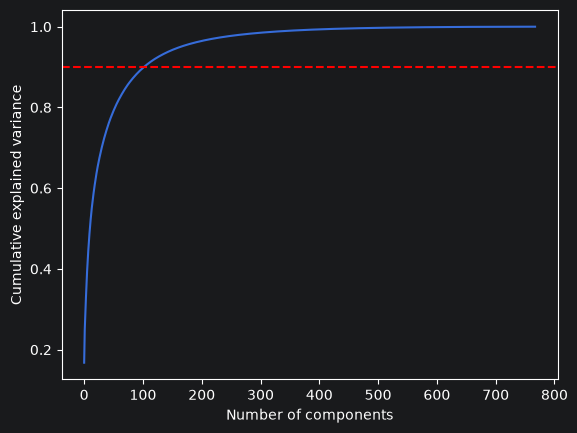

Components needed for 90% variance: 103


In [90]:
# # just the emb_ columns, nothing else
# emb_cols = [c for c in monthly_region_embeddings.columns if c.startswith("emb_")]
# X = df_final[emb_cols].values
#
# pca = PCA()
# pca.fit(X)
#
# cumulative_variance = pca.explained_variance_ratio_.cumsum()
#
# plt.plot(cumulative_variance)
# plt.xlabel("Number of components")
# plt.ylabel("Cumulative explained variance")
# plt.axhline(y=0.90, color='r', linestyle='--')
# plt.show()
#
# # how many components needed for 90% variance
# n_components_90 = (cumulative_variance < 0.90).sum() + 1
# print(f"Components needed for 90% variance: {n_components_90}")

In [115]:
df_final_pcs.to_pickle("pca_components.pkl")